# 07 — EfficientNet-B0 Baseline

CNN baseline for the RSNA knee MRI multi-label task. The model uses 2.5D neighbouring slices as a pretrained EfficientNet-B0 input, then mean-pools instance logits to obtain one study-level prediction for the 12 abnormalities.

**Experiment mode:** `SMOKE_TEST=True` is only for pipeline validation. The final experiment uses all 58 gold-labelled studies with the corrected study-level folds from Notebook 05.

In [1]:
# ==================================================
# 01 — Startup / configuration
# ==================================================

import os
import gc
import glob
import random
import warnings
from functools import lru_cache

print("[1/3] Loading NumPy/Pandas...", flush=True)
import numpy as np
import pandas as pd
print("      OK", flush=True)

print("[2/3] Loading PyTorch...", flush=True)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
print(f"      PyTorch {torch.__version__} OK", flush=True)

print("[3/3] Setting configuration...", flush=True)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IMAGE_SIZE = 224
NUM_CLASSES = 12
N_FOLDS = 5

# --------------------------------------------------
# Experiment mode
# --------------------------------------------------
# True  -> pipeline smoke test
# False -> real 58-study gold experiment after corrected 04/05
SMOKE_TEST = False
SMOKE_GOLD_LIMIT = 5

# --------------------------------------------------
# Training configuration
# --------------------------------------------------
EPOCHS = 3

# One study per batch because each study may contain
# a different number of 2.5D instances.
STUDY_BATCH_SIZE = 1

# To control GPU memory/time, sample a maximum number
# of 2.5D instances per study.
MAX_TRAIN_INSTANCES = 24
MAX_VAL_INSTANCES = 48

INSTANCE_BATCH_SIZE = 8

# Multiprocessing is unnecessary for this small smoke-test
# dataset and can create worker cleanup warnings in Kaggle.
NUM_WORKERS = 0

FREEZE_BACKBONE = True

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

# Fixed threshold for the common comparison protocol.
# Threshold tuning can be studied separately later.
CLASSIFICATION_THRESHOLD = 0.50

# Model selection inside each fold uses validation loss.
# This remains defined even when a rare label is absent
# from the validation fold.

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
USE_AMP = DEVICE.type == "cuda"

print("Device:", DEVICE, flush=True)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0), flush=True)

print("Smoke test:", SMOKE_TEST, flush=True)
print("Startup complete.", flush=True)


[1/3] Loading NumPy/Pandas...
      OK
[2/3] Loading PyTorch...
      PyTorch 2.11.0+cu128 OK
[3/3] Setting configuration...
Device: cuda
GPU: Tesla T4
Smoke test: False
Startup complete.


## Data and split setup

This notebook consumes the shared outputs from Notebooks 03–05: preprocessed `.npy` volumes, the 2.5D index, and **study-level** cross-validation folds. Labels remain at study level, so the same study must never cross folds.

The real run is therefore: **58 complete gold studies → 5 study-level folds → held-out validation per fold**. The report-derived weak labels are not used in this CNN baseline.

In [2]:
# ==================================================
# Dataset / artifact discovery — Kaggle-safe
# ==================================================
# IMPORTANT: never recursively scan the contents of huge DICOM or
# processed_data folders just to find a small CSV. The previous version
# could appear frozen because glob(**) walked enormous trees.

SEARCH_ROOTS = ["/kaggle/input", "/kaggle/working"]

PRUNE_DIRS = {
    "processed_data",
    "train_images",
    "test_images",
    "train_series",
    "test_series",
    "__pycache__",
    ".git"
}


def find_all(filename, max_matches=20):
    matches = []

    for root in SEARCH_ROOTS:
        if not os.path.exists(root):
            continue

        for current, dirs, files in os.walk(root):
            # Do not descend into giant image/volume directories.
            dirs[:] = [d for d in dirs if d not in PRUNE_DIRS]

            if filename in files:
                matches.append(os.path.join(current, filename))
                if len(matches) >= max_matches:
                    return sorted(set(matches))

    return sorted(set(matches))


def find_processed_roots():
    roots = []

    for root in SEARCH_ROOTS:
        if not os.path.exists(root):
            continue

        for current, dirs, files in os.walk(root):
            # Detect processed_data, but never recurse into it.
            keep = []
            for d in dirs:
                full = os.path.join(current, d)
                if d == "processed_data":
                    roots.append(full)
                else:
                    keep.append(d)
            dirs[:] = [d for d in keep if d not in {"train_images", "test_images", "train_series", "test_series", "__pycache__", ".git"}]

    return sorted(set(os.path.normpath(p) for p in roots if os.path.isdir(p)))


def choose_artifact(filename, preferred_tokens=()):
    candidates = find_all(filename)

    if not candidates:
        return None

    for token in preferred_tokens:
        token = token.lower()
        for path in candidates:
            if token in path.lower():
                return path

    if len(candidates) == 1:
        return candidates[0]

    return candidates[0]


# --------------------------------------------------
# Competition data
# --------------------------------------------------
competition_candidates = find_all("train.csv")
competition_candidates = [
    p for p in competition_candidates
    if "rsna" in p.lower() and "knee" in p.lower()
]

# Fallback: Kaggle sometimes gives the dataset a different folder name.
if not competition_candidates:
    generic_train = find_all("train.csv")
    if generic_train:
        competition_candidates = generic_train

if not competition_candidates:
    raise FileNotFoundError(
        "RSNA train.csv not found. Attach the RSNA Knee Abnormality Detection dataset as an input."
    )

COMP_DIR = os.path.dirname(competition_candidates[0])

# --------------------------------------------------
# Notebook 04 / 05 artifacts
# --------------------------------------------------
p2d_path = choose_artifact(
    "2p5d_index.csv",
    preferred_tokens=("04_2.5d", "04-2.5d", "04_2p5d", "04-2p5d")
)

if p2d_path is None:
    raise FileNotFoundError(
        "2p5d_index.csv not found. Attach the Notebook 04 output as a Kaggle input."
    )

cv_index_path = choose_artifact(
    "2p5d_index_with_folds.csv",
    preferred_tokens=("05_cv_splits", "05-cv-splits", "05_cv", "05-cv")
)

if cv_index_path is None:
    raise FileNotFoundError(
        "2p5d_index_with_folds.csv not found. Attach the Notebook 05 output as a Kaggle input."
    )

cv_path = choose_artifact(
    "cv_folds.csv",
    preferred_tokens=("05_cv_splits", "05-cv-splits", "05_cv", "05-cv")
)

processed_roots = find_processed_roots()
prep_metadata_candidates = find_all("processed_metadata.csv")
prep_metadata_path = prep_metadata_candidates[0] if prep_metadata_candidates else None

print("\nCompetition directory:")
print(COMP_DIR)
print("\nNotebook 04 2.5D index:")
print(p2d_path)
print("\nNotebook 05 2.5D + folds:")
print(cv_index_path)
print("\nNotebook 05 folds:")
print(cv_path if cv_path else "Derived from combined index")
print("\nMounted processed_data directories:")
if processed_roots:
    for p in processed_roots:
        print(p)
else:
    print("NONE FOUND")
print("\nNotebook 03 processed_metadata.csv:")
print(prep_metadata_path if prep_metadata_path else "OPTIONAL / NOT FOUND")



Competition directory:
/kaggle/input/competitions/rsna-knee-abnormality-detection

Notebook 04 2.5D index:
/kaggle/input/notebooks/shambhavisinha254/04-2-5d/2p5d_index.csv

Notebook 05 2.5D + folds:
/kaggle/input/notebooks/shambhavisinha254/05-cv-splits/2p5d_index_with_folds.csv

Notebook 05 folds:
/kaggle/input/notebooks/shambhavisinha254/05-cv-splits/cv_folds.csv

Mounted processed_data directories:
/kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_data

Notebook 03 processed_metadata.csv:
/kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_metadata.csv


In [3]:
train = pd.read_csv(
    os.path.join(
        COMP_DIR,
        "train.csv"
    )
)

index_2p5d = pd.read_csv(
    cv_index_path
)

if cv_path is not None:
    cv_folds = pd.read_csv(cv_path)
else:
    if "fold" not in index_2p5d.columns:
        raise RuntimeError(
            "cv_folds.csv is missing and the combined 2.5D artifact "
            "does not contain a 'fold' column."
        )
    cv_folds = (
        index_2p5d[["StudyInstanceUID", "fold"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

LABEL_COLS = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

print(
    "Total train studies:",
    len(train)
)

print(
    "CV fold rows:",
    len(cv_folds)
)

print(
    "2.5D rows:",
    len(index_2p5d)
)

print(
    "CV studies:",
    cv_folds[
        "StudyInstanceUID"
    ].nunique()
)

print(
    "2.5D studies:",
    index_2p5d[
        "StudyInstanceUID"
    ].nunique()
)


Total train studies: 4407
CV fold rows: 58
2.5D rows: 10528
CV studies: 58
2.5D studies: 58


In [4]:
gold_df = train.dropna(
    subset=LABEL_COLS
).copy()

print(
    "Complete gold studies:",
    len(gold_df)
)

if SMOKE_TEST:

    gold_df = gold_df.head(
        SMOKE_GOLD_LIMIT
    ).copy()

    print(
        "\nSMOKE TEST MODE"
    )

    print(
        "Gold studies used:",
        len(gold_df)
    )

else:

    if len(gold_df) < 50:
        raise RuntimeError(
            f"""
STOP.

Only {len(gold_df)} gold-labelled studies are visible.

The real experiment requires the complete gold subset.
Your current 04/05 artifacts are probably still based
on the 500-study development subset.
"""
        )

# --------------------------------------------------
# Check fold availability
# --------------------------------------------------

gold_ids = set(
    gold_df[
        "StudyInstanceUID"
    ]
)

cv_gold = cv_folds[
    cv_folds[
        "StudyInstanceUID"
    ].isin(gold_ids)
].copy()

print(
    "Gold studies present in CV:",
    cv_gold[
        "StudyInstanceUID"
    ].nunique()
)

if not SMOKE_TEST and (
    cv_gold[
        "StudyInstanceUID"
    ].nunique()
    != len(gold_df)
):

    raise RuntimeError(
        """
STOP.

Not all gold studies have fold assignments.

Wait for the corrected Notebook 05.
"""
    )

Complete gold studies: 58
Gold studies present in CV: 58


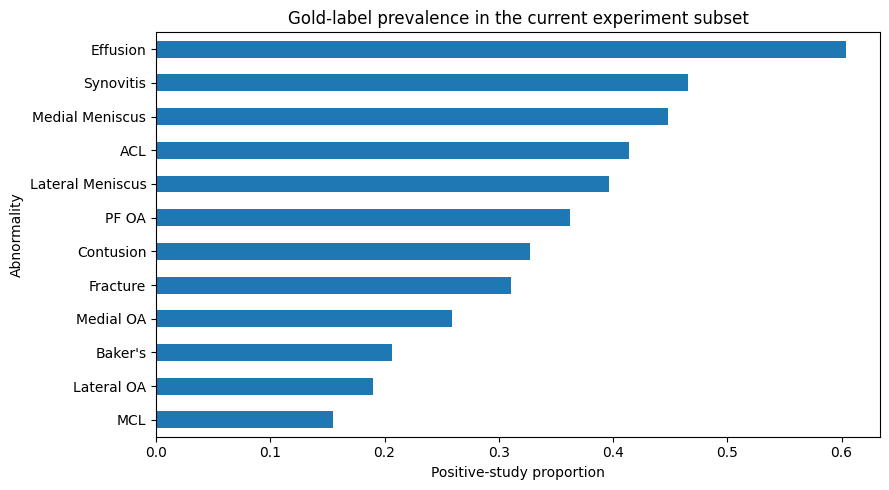

Positive counts per label:


,positive_studies
Effusion,35.0
Synovitis,27.0
Medial Meniscus,26.0
ACL,24.0
Lateral Meniscus,23.0
PF OA,21.0
Contusion,19.0
Fracture,18.0
Medial OA,15.0
Baker's,12.0


In [5]:
# ==================================================
# 04A — Label prevalence diagnostic
# ==================================================

import matplotlib.pyplot as plt

gold_prevalence = (
    gold_df[LABEL_COLS]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
gold_prevalence.plot(kind="barh")

plt.xlabel("Positive-study proportion")
plt.ylabel("Abnormality")
plt.title("Gold-label prevalence in the current experiment subset")

plt.tight_layout()
plt.show()

print("Positive counts per label:")

display(
    gold_df[LABEL_COLS]
    .sum()
    .sort_values(ascending=False)
    .to_frame("positive_studies")
)

In [6]:
covered_gold = index_2p5d[
    index_2p5d[
        "StudyInstanceUID"
    ].isin(gold_ids)
][
    "StudyInstanceUID"
].unique()

covered_gold = set(
    covered_gold
)

missing = sorted(
    gold_ids - covered_gold
)

print(
    "Gold studies:",
    len(gold_ids)
)

print(
    "Gold studies with 2.5D data:",
    len(covered_gold)
)

print(
    "Missing gold studies:",
    len(missing)
)

if missing:
    print(
        "\nFirst missing IDs:"
    )

    for sid in missing[:5]:
        print(sid)

if not SMOKE_TEST and missing:

    raise RuntimeError(
        f"""
STOP.

{len(missing)} gold studies are missing
from the 2.5D artifact.

Notebook 03/04 must be regenerated.
"""
    )

index_2p5d = index_2p5d[
    index_2p5d[
        "StudyInstanceUID"
    ].isin(gold_ids)
].copy()

print(
    "\nGold 2.5D rows:",
    len(index_2p5d)
)

Gold studies: 58
Gold studies with 2.5D data: 58
Missing gold studies: 0

Gold 2.5D rows: 10528


In [7]:
required_cols = [
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "File_Path",
    "Num_Slices",
    "Prev_Slice_Index",
    "Center_Slice_Index",
    "Next_Slice_Index"
]

missing_cols = [
    c for c in required_cols
    if c not in index_2p5d.columns
]

if missing_cols:
    raise RuntimeError(
        "Missing required columns: "
        + str(missing_cols)
    )

print(
    "All required 2.5D columns found."
)

print(
    index_2p5d[
        required_cols
    ].head()
)

All required 2.5D columns found.
                                    StudyInstanceUID  \
0  1.2.826.0.1.3680043.8.498.10095687747295410396...   
1  1.2.826.0.1.3680043.8.498.10095687747295410396...   
2  1.2.826.0.1.3680043.8.498.10095687747295410396...   
3  1.2.826.0.1.3680043.8.498.10095687747295410396...   
4  1.2.826.0.1.3680043.8.498.10095687747295410396...   

                                   SeriesInstanceUID  \
0  1.2.826.0.1.3680043.8.498.10791858932231443712...   
1  1.2.826.0.1.3680043.8.498.10791858932231443712...   
2  1.2.826.0.1.3680043.8.498.10791858932231443712...   
3  1.2.826.0.1.3680043.8.498.10791858932231443712...   
4  1.2.826.0.1.3680043.8.498.10791858932231443712...   

                                           File_Path  Num_Slices  \
0  /kaggle/input/notebooks/shambhavisinha254/03-5...          36   
1  /kaggle/input/notebooks/shambhavisinha254/03-5...          36   
2  /kaggle/input/notebooks/shambhavisinha254/03-5...          36   
3  /kaggle/input/note

In [8]:
# --------------------------------------------------
# Attach study-level fold assignments to BOTH:
#   1. gold_df       -> used by train_fold()
#   2. index_2p5d    -> used by dataset/index filtering
# --------------------------------------------------

study_info = gold_df[
    ["StudyInstanceUID"] + LABEL_COLS
].copy()

# One row per study with its CV fold.
study_info = study_info.merge(
    cv_folds[
        ["StudyInstanceUID", "fold"]
    ],
    on="StudyInstanceUID",
    how="left"
)

# Every gold study must have a fold.
if study_info["fold"].isna().any():

    missing_fold_studies = (
        study_info.loc[
            study_info["fold"].isna(),
            "StudyInstanceUID"
        ]
        .tolist()
    )

    raise RuntimeError(
        "Some gold studies do not have a fold assignment: "
        + str(missing_fold_studies[:10])
    )

# IMPORTANT FIX:
# train_fold() reads gold_df["fold"], so fold must be
# explicitly added back to gold_df.
gold_df = gold_df.drop(
    columns=["fold"],
    errors="ignore"
).merge(
    study_info[
        ["StudyInstanceUID", "fold"]
    ],
    on="StudyInstanceUID",
    how="left"
)

# If this cell is re-run, remove previously merged derived
# columns first to avoid fold_x/fold_y or duplicate labels.
derived_cols = ["fold"] + LABEL_COLS

index_2p5d = index_2p5d.drop(
    columns=[
        c for c in derived_cols
        if c in index_2p5d.columns
    ],
    errors="ignore"
)

index_2p5d = index_2p5d.merge(
    study_info[
        ["StudyInstanceUID", "fold"] + LABEL_COLS
    ],
    on="StudyInstanceUID",
    how="left"
)

print("gold_df columns now include fold:", "fold" in gold_df.columns)
print("index_2p5d columns now include fold:", "fold" in index_2p5d.columns)

print(
    "\nFold distribution:"
)

print(
    study_info[
        "fold"
    ].value_counts().sort_index()
)

print(
    "\nGold studies by fold:"
)

print(
    gold_df[
        ["StudyInstanceUID", "fold"]
    ].value_counts("fold").sort_index()
)


gold_df columns now include fold: True
index_2p5d columns now include fold: True

Fold distribution:
fold
0    12
1    12
2    12
3    11
4    11
Name: count, dtype: int64

Gold studies by fold:
fold
0    12
1    12
2    12
3    11
4    11
Name: count, dtype: int64


In [9]:
# --------------------------------------------------
# Robust processed-volume path resolution
# --------------------------------------------------

def resolve_volume_path(original_path):

    original_path = str(original_path)

    # Case 1: path is already valid in the current Kaggle session.
    if os.path.exists(original_path):
        return original_path

    # Case 2: resolve from the processed_data/ relative suffix.
    marker_options = [
        "/processed_data/",
        "\\processed_data\\"
    ]

    suffix = None

    for marker in marker_options:
        if marker in original_path:
            suffix = original_path.split(marker, 1)[1]
            break

    if suffix is not None:

        for processed_root in processed_roots:
            candidate = os.path.join(
                processed_root,
                suffix.replace("\\", os.sep).replace("/", os.sep)
            )

            if os.path.exists(candidate):
                return candidate

    # Case 3: fallback by filename inside every mounted processed_data tree.
    basename = os.path.basename(
        original_path.replace("\\", "/")
    )

    for processed_root in processed_roots:
        matches = glob.glob(
            os.path.join(
                processed_root,
                "**",
                basename
            ),
            recursive=True
        )

        if matches:
            return sorted(matches)[0]

    raise FileNotFoundError(
        "Processed volume could not be resolved.\n\n"
        f"Original path:\n{original_path}\n\n"
        "Mounted processed_data directories:\n"
        + ("\n".join(processed_roots) if processed_roots else "NONE")
        + "\n\n"
        "ACTION: attach the Notebook 03 preprocessing output "
        "containing the processed_data/ .npy files to this Kaggle notebook."
    )


test_resolved = resolve_volume_path(
    index_2p5d["File_Path"].iloc[0]
)

print("Resolved volume:", test_resolved)
print("Exists:", os.path.exists(test_resolved))


Resolved volume: /kaggle/input/notebooks/shambhavisinha254/03-58-studies/processed_data/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.10791858932231443712736629517371931282.npy
Exists: True


## 2.5D study dataset and image construction

Each study may contain many 2.5D instances. To control memory, a deterministic subset of instances is sampled per study. Each instance stacks previous/current/next slices as three channels, preserving compatibility with ImageNet-pretrained EfficientNet-B0.

In [10]:
class StudyDataset(
    Dataset
):

    def __init__(
        self,
        index_df,
        study_df,
        max_instances,
        sampling_seed
    ):

        self.index_df = (
            index_df.reset_index(
                drop=True
            )
        )

        self.study_df = (
            study_df.reset_index(
                drop=True
            )
        )

        self.max_instances = (
            max_instances
        )

        self.sampling_seed = (
            sampling_seed
        )

        self.study_ids = (
            self.study_df[
                "StudyInstanceUID"
            ].tolist()
        )

        self.grouped = {}

        for study_id in self.study_ids:

            self.grouped[
                study_id
            ] = self.index_df[
                self.index_df[
                    "StudyInstanceUID"
                ] == study_id
            ].reset_index(
                drop=True
            )

    def __len__(self):

        return len(
            self.study_ids
        )

    def __getitem__(
        self,
        idx
    ):

        study_id = (
            self.study_ids[idx]
        )

        rows = self.grouped[
            study_id
        ].copy()

        if (
            self.max_instances is not None
            and len(rows) > self.max_instances
        ):

            rows = rows.sample(
                n=self.max_instances,
                random_state=(
                    self.sampling_seed
                    + idx
                )
            )

        study_row = self.study_df[
            self.study_df[
                "StudyInstanceUID"
            ] == study_id
        ].iloc[0]

        labels = (
            study_row[
                LABEL_COLS
            ]
            .values
            .astype(
                np.float32
            )
        )

        return (
            rows.to_dict(
                "records"
            ),
            torch.tensor(
                labels,
                dtype=torch.float32
            ),
            study_id
        )


def study_collate(
    batch
):

    return batch[0]

In [11]:
IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32
).view(3, 1, 1)


@lru_cache(maxsize=8)
def load_volume(
    path
):

    return np.load(
        path,
        mmap_mode="r"
    )


def load_2p5d_sample(
    row
):

    path = resolve_volume_path(
        row["File_Path"]
    )

    volume = load_volume(
        path
    )

    p = int(
        row["Prev_Slice_Index"]
    )

    c = int(
        row["Center_Slice_Index"]
    )

    n = int(
        row["Next_Slice_Index"]
    )

    x = np.stack(
        [
            volume[p],
            volume[c],
            volume[n]
        ],
        axis=0
    ).astype(
        np.float32
    )

    if x.shape[1:] != (
        IMAGE_SIZE,
        IMAGE_SIZE
    ):

        raise ValueError(
            f"Unexpected shape: {x.shape}"
        )

    x = torch.from_numpy(
        x
    )

    x = (
        x - IMAGENET_MEAN
    ) / IMAGENET_STD

    return x

## EfficientNet-B0 baseline and study-level aggregation

EfficientNet-B0 provides the convolutional feature extractor and a 12-output multi-label head. Instance logits are **mean-pooled at study level** before the weighted BCE loss is applied.

This fixed mean-pooling baseline is intentionally simpler than the later attention-based DINOv2 + MIL model, making the comparison interpretable.

In [12]:
def build_model():
    # Import torchvision here, not during notebook startup.
    from torchvision.models import (
        efficientnet_b0,
        EfficientNet_B0_Weights
    )

    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

    if FREEZE_BACKBONE:
        for p in model.features.parameters():
            p.requires_grad = False
        for p in model.classifier.parameters():
            p.requires_grad = True

    return model.to(DEVICE)


model = build_model()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 217MB/s]


Total parameters: 4022920
Trainable parameters: 15372


In [13]:
def study_forward(
    model,
    rows
):

    # --------------------------------------------------
    # Load all selected 2.5D instances
    # --------------------------------------------------

    tensors = []

    for row in rows:

        tensors.append(
            load_2p5d_sample(row)
        )

    x = torch.stack(
        tensors
    )

    logits_chunks = []

    # --------------------------------------------------
    # Process instances in smaller GPU batches
    # --------------------------------------------------

    for start in range(
        0,
        len(x),
        INSTANCE_BATCH_SIZE
    ):

        xb = x[
            start:
            start + INSTANCE_BATCH_SIZE
        ].to(
            DEVICE,
            non_blocking=True
        )

        logits = model(
            xb
        )

        logits_chunks.append(
            logits
        )

    all_logits = torch.cat(
        logits_chunks,
        dim=0
    )

    # Simple mean pooling baseline
    study_logits = (
        all_logits.mean(
            dim=0
        )
    )

    return study_logits

## Training and common evaluation protocol

Training uses class-weighted binary cross-entropy to reduce the effect of label imbalance. The same study-level folds, 2.5D sampling limits, threshold and core metrics should be reused by the ViT and DINOv2 models so the final comparison is fair.

The notebook reports macro ROC-AUC/PR-AUC, macro precision/recall/F1, macro specificity, micro F1, Hamming loss and subset accuracy. Checkpoint selection uses validation loss because rare labels may be absent from an individual fold.

In [14]:
def create_pos_weight(
    train_studies
):

    y = train_studies[
        LABEL_COLS
    ].values.astype(
        np.float32
    )

    positives = y.sum(
        axis=0
    )

    negatives = (
        len(y) - positives
    )

    weights = np.ones(
        NUM_CLASSES,
        dtype=np.float32
    )

    valid = positives > 0

    weights[valid] = (
        negatives[valid]
        /
        positives[valid]
    )

    # Prevent extreme weights from
    # destabilizing the preliminary baseline
    weights = np.clip(
        weights,
        1.0,
        20.0
    )

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE
    )

In [15]:
# ==================================================
# 14 — Evaluation utilities
# ==================================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
    accuracy_score,
    roc_curve,
    precision_recall_curve
)


def compute_per_class_metrics(
    y_true,
    y_prob,
    threshold=CLASSIFICATION_THRESHOLD
):
    """
    Return one row per abnormality.

    ROC-AUC / PR-AUC are only defined when both positive
    and negative examples occur in the evaluation subset.
    """
    y_pred = (y_prob >= threshold).astype(int)

    rows = []

    for j, label in enumerate(LABEL_COLS):
        true_j = y_true[:, j].astype(int)
        prob_j = y_prob[:, j]
        pred_j = y_pred[:, j]

        tp = int(np.sum((true_j == 1) & (pred_j == 1)))
        tn = int(np.sum((true_j == 0) & (pred_j == 0)))
        fp = int(np.sum((true_j == 0) & (pred_j == 1)))
        fn = int(np.sum((true_j == 1) & (pred_j == 0)))

        precision = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else np.nan
        )
        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )
        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )
        f1 = (
            2 * precision * recall / (precision + recall)
            if (
                np.isfinite(precision)
                and np.isfinite(recall)
                and (precision + recall) > 0
            )
            else 0.0
        )

        auc = (
            roc_auc_score(true_j, prob_j)
            if len(np.unique(true_j)) == 2
            else np.nan
        )

        pr_auc = (
            average_precision_score(true_j, prob_j)
            if len(np.unique(true_j)) == 2
            else np.nan
        )

        rows.append({
            "label": label,
            "prevalence": float(true_j.mean()),
            "positive_count": int(true_j.sum()),
            "precision": precision,
            "recall": recall,
            "sensitivity": recall,
            "specificity": specificity,
            "f1": f1,
            "roc_auc": auc,
            "pr_auc": pr_auc,
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn
        })

    return pd.DataFrame(rows)


def compute_metrics(
    y_true,
    y_prob,
    threshold=CLASSIFICATION_THRESHOLD
):
    """
    Study-level multi-label metrics.

    Macro metrics give each abnormality equal weight.
    Micro F1 pools all label decisions together.
    """
    y_pred = (y_prob >= threshold).astype(int)

    per_class = compute_per_class_metrics(
        y_true,
        y_prob,
        threshold=threshold
    )

    valid_auc = per_class["roc_auc"].dropna()
    valid_pr = per_class["pr_auc"].dropna()

    metrics = {
        "macro_auc": valid_auc.mean() if len(valid_auc) else np.nan,
        "macro_pr_auc": valid_pr.mean() if len(valid_pr) else np.nan,
        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "macro_specificity": per_class["specificity"].mean(),
        "micro_f1": f1_score(
            y_true,
            y_pred,
            average="micro",
            zero_division=0
        ),
        "hamming_loss": hamming_loss(
            y_true,
            y_pred
        ),
        "subset_accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "valid_auc_classes": int(len(valid_auc)),
        "valid_pr_auc_classes": int(len(valid_pr))
    }

    return metrics


print("Evaluation utilities ready.")


Evaluation utilities ready.


In [16]:
# ==================================================
# 15 — Train one study-level fold
# ==================================================

from tqdm.auto import tqdm


def train_fold(fold):
    print("=" * 70)
    print(f"EfficientNet-B0 | FOLD {fold}")
    print("=" * 70)

    train_studies = gold_df[
        gold_df["fold"] != fold
    ].copy()

    val_studies = gold_df[
        gold_df["fold"] == fold
    ].copy()

    train_index = index_2p5d[
        index_2p5d["StudyInstanceUID"].isin(
            train_studies["StudyInstanceUID"]
        )
    ].copy()

    val_index = index_2p5d[
        index_2p5d["StudyInstanceUID"].isin(
            val_studies["StudyInstanceUID"]
        )
    ].copy()

    if train_studies.empty or val_studies.empty:
        raise RuntimeError(
            f"Fold {fold} has an empty train or validation split."
        )

    print("Train studies:", len(train_studies))
    print("Validation studies:", len(val_studies))
    print("Train 2.5D rows:", len(train_index))
    print("Validation 2.5D rows:", len(val_index))

    train_ds = StudyDataset(
        train_index,
        train_studies,
        MAX_TRAIN_INSTANCES,
        SEED + fold
    )

    val_ds = StudyDataset(
        val_index,
        val_studies,
        MAX_VAL_INSTANCES,
        SEED + 100 + fold
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=STUDY_BATCH_SIZE,
        shuffle=True,
        collate_fn=study_collate,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda")
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=1,
        shuffle=False,
        collate_fn=study_collate,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda")
    )

    model = build_model()

    pos_weight = create_pos_weight(
        train_studies
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.AdamW(
        [
            p for p in model.parameters()
            if p.requires_grad
        ],
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=USE_AMP
    )

    history = []

    # Validation-loss model selection is robust when rare labels
    # are absent from a particular validation fold.
    best_val_loss = np.inf
    best_state = None

    for epoch in range(EPOCHS):
        model.train()

        # Keep the frozen pretrained feature extractor in eval mode so
        # its BatchNorm running statistics are not updated during fine-tuning.
        if FREEZE_BACKBONE:
            model.features.eval()
        running_loss = 0.0

        for rows, y, study_id in tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}",
            leave=False
        ):
            y = y.to(DEVICE)

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                device_type=DEVICE.type,
                enabled=USE_AMP
            ):
                study_logits = study_forward(
                    model,
                    rows
                )

                loss = criterion(
                    study_logits.unsqueeze(0),
                    y.unsqueeze(0)
                )

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        train_loss = (
            running_loss /
            max(len(train_loader), 1)
        )

        # -------------------------------
        # Validation
        # -------------------------------
        model.eval()

        truths = []
        probs = []
        ids = []
        validation_loss = 0.0

        with torch.no_grad():
            for rows, y, study_id in tqdm(
                val_loader,
                desc="Validation",
                leave=False
            ):
                study_logits = study_forward(
                    model,
                    rows
                )

                val_loss = criterion(
                    study_logits.unsqueeze(0),
                    y.to(DEVICE).unsqueeze(0)
                )

                validation_loss += val_loss.item()

                study_prob = (
                    torch.sigmoid(study_logits)
                    .cpu()
                    .numpy()
                )

                truths.append(
                    y.numpy()
                )
                probs.append(
                    study_prob
                )
                ids.append(
                    study_id
                )

        y_true = np.vstack(truths)
        y_prob = np.vstack(probs)

        metrics = compute_metrics(
            y_true,
            y_prob
        )

        val_loss = (
            validation_loss /
            max(len(val_loader), 1)
        )

        history.append({
            "fold": fold,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **metrics
        })

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"TrainLoss={train_loss:.4f} | "
            f"ValLoss={val_loss:.4f} | "
            f"MacroAUC={metrics['macro_auc']:.4f} | "
            f"MacroPRAUC={metrics['macro_pr_auc']:.4f} | "
            f"MacroF1={metrics['macro_f1']:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    if best_state is not None:
        model.load_state_dict(best_state)

    # -------------------------------
    # Final validation with best model
    # -------------------------------
    model.eval()

    truths = []
    probs = []
    ids = []
    final_val_loss = 0.0

    with torch.no_grad():
        for rows, y, study_id in tqdm(
            val_loader,
            desc="Best-model validation",
            leave=False
        ):
            study_logits = study_forward(
                model,
                rows
            )

            batch_loss = criterion(
                study_logits.unsqueeze(0),
                y.to(DEVICE).unsqueeze(0)
            )

            final_val_loss += batch_loss.item()

            study_prob = (
                torch.sigmoid(study_logits)
                .cpu()
                .numpy()
            )

            truths.append(
                y.numpy()
            )
            probs.append(
                study_prob
            )
            ids.append(
                study_id
            )

    y_true = np.vstack(truths)
    y_prob = np.vstack(probs)

    final_metrics = compute_metrics(
        y_true,
        y_prob
    )

    final_metrics["best_val_loss"] = (
        final_val_loss /
        max(len(val_loader), 1)
    )

    checkpoint_path = (
        f"/kaggle/working/"
        f"efficientnet_b0_fold_{fold}.pth"
    )

    torch.save(
        model.state_dict(),
        checkpoint_path
    )

    history_df = pd.DataFrame(history)

    history_path = (
        f"/kaggle/working/"
        f"efficientnet_history_fold_{fold}.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    per_class_df = compute_per_class_metrics(
        y_true,
        y_prob
    )
    per_class_df.insert(
        0,
        "fold",
        fold
    )

    per_class_path = (
        f"/kaggle/working/"
        f"efficientnet_per_class_metrics_fold_{fold}.csv"
    )

    per_class_df.to_csv(
        per_class_path,
        index=False
    )

    print("\nFinal fold metrics:")
    print(final_metrics)

    print("\nCheckpoint:", checkpoint_path)
    print("History:", history_path)
    print("Per-class metrics:", per_class_path)

    prediction_rows = []

    for i, sid in enumerate(ids):
        # DataLoader returns the single-study ID for batch_size=1.
        if isinstance(sid, (list, tuple)):
            sid = sid[0]

        row = {
            "StudyInstanceUID": sid,
            "fold": fold
        }

        for j, label in enumerate(LABEL_COLS):
            row[f"{label}_true"] = y_true[i, j]
            row[f"{label}_prob"] = y_prob[i, j]

        prediction_rows.append(row)

    pred_df = pd.DataFrame(
        prediction_rows
    )

    pred_path = (
        f"/kaggle/working/"
        f"efficientnet_predictions_fold_{fold}.csv"
    )

    pred_df.to_csv(
        pred_path,
        index=False
    )

    return (
        final_metrics,
        pred_df,
        history_df,
        per_class_df
    )


## Cross-validation results and diagnostics

The completed folds produce out-of-fold predictions and a compact comparison row. The later cells add training curves, per-abnormality metrics, ROC/PR curves and study-level error analysis.

With the smoke test, these diagnostics are only pipeline checks. They become reportable after the full 58-study five-fold run.

In [17]:
# ==================================================
# 16 — Run folds
# ==================================================

fold_results = []
all_predictions = []
all_histories = []
all_per_class = []

RUN_FOLDS = (
    1
    if SMOKE_TEST
    else N_FOLDS
)

for fold in range(RUN_FOLDS):
    (
        metrics,
        pred_df,
        history_df,
        per_class_df
    ) = train_fold(fold)

    fold_results.append({
        "fold": fold,
        **metrics
    })

    all_predictions.append(
        pred_df
    )

    all_histories.append(
        history_df
    )

    all_per_class.append(
        per_class_df
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(
    f"Completed {RUN_FOLDS} fold(s)."
)


EfficientNet-B0 | FOLD 0
Train studies: 46
Validation studies: 12
Train 2.5D rows: 8251
Validation 2.5D rows: 2277


Epoch 1:   0%|          | 0/46 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/3 | TrainLoss=0.9063 | ValLoss=0.8851 | MacroAUC=0.5135 | MacroPRAUC=0.4454 | MacroF1=0.2166


Epoch 2:   0%|          | 0/46 [00:00<?, ?it/s]

...

Epoch 3:   0%|          | 0/47 [00:00<?, ?it/s]

Validation:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 3/3 | TrainLoss=0.9314 | ValLoss=1.1090 | MacroAUC=0.6269 | MacroPRAUC=0.5800 | MacroF1=0.2694


Best-model validation:   0%|          | 0/11 [00:00<?, ?it/s]


Final fold metrics:
{'macro_auc': np.float64(0.618915343915344), 'macro_pr_auc': np.float64(0.5739742951052476), 'macro_precision': 0.19823232323232323, 'macro_recall': 0.15277777777777776, 'macro_f1': 0.14929971988795518, 'macro_specificity': np.float64(0.8595238095238096), 'micro_f1': 0.28169014084507044, 'hamming_loss': 0.38636363636363635, 'subset_accuracy': 0.0, 'valid_auc_classes': 12, 'valid_pr_auc_classes': 12, 'best_val_loss': 1.104883161458102}

Checkpoint: /kaggle/working/efficientnet_b0_fold_4.pth
History: /kaggle/working/efficientnet_history_fold_4.csv
Per-class metrics: /kaggle/working/efficientnet_per_class_metrics_fold_4.csv
Completed 5 fold(s).


In [18]:
# ==================================================
# 17 — Fold summary / comparison row
# ==================================================

results_df = pd.DataFrame(
    fold_results
)

display(
    results_df
)

results_path = (
    "/kaggle/working/"
    "efficientnet_b0_fold_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

all_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

oof_path = (
    "/kaggle/working/"
    "efficientnet_b0_oof_predictions.csv"
)

all_predictions_df.to_csv(
    oof_path,
    index=False
)

# Mean ± std across completed folds.
metric_cols = [
    "macro_auc",
    "macro_pr_auc",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "macro_specificity",
    "micro_f1",
    "hamming_loss",
    "subset_accuracy"
]

summary_rows = []

for metric in metric_cols:
    summary_rows.append({
        "metric": metric,
        "mean": results_df[metric].mean(),
        "std": results_df[metric].std(ddof=1)
        if len(results_df) > 1
        else np.nan
    })

summary_df = pd.DataFrame(summary_rows)

display(
    summary_df
)

summary_path = (
    "/kaggle/working/"
    "efficientnet_b0_metric_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

comparison_row = {
    "model": "EfficientNet-B0",
    "input": "2.5D previous/current/next slices",
    "aggregation": "mean instance-logit pooling",
    "loss": "weighted BCE",
    "threshold": CLASSIFICATION_THRESHOLD,
    "folds_completed": RUN_FOLDS
}

for metric in metric_cols:
    row = summary_df[
        summary_df["metric"] == metric
    ].iloc[0]

    comparison_row[f"{metric}_mean"] = row["mean"]
    comparison_row[f"{metric}_std"] = row["std"]

comparison_df = pd.DataFrame([comparison_row])

comparison_path = (
    "/kaggle/working/"
    "efficientnet_b0_comparison_row.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("\nSaved:")
print(results_path)
print(oof_path)
print(summary_path)
print(comparison_path)


,fold,macro_auc,macro_pr_auc,macro_precision,macro_recall,macro_f1,macro_specificity,micro_f1,hamming_loss,subset_accuracy,valid_auc_classes,valid_pr_auc_classes,best_val_loss
0,0,0.513522,0.445385,0.231944,0.252083,0.216601,0.783333,0.410959,0.298611,0.083333,10,10,0.885080
1,1,0.650857,0.625336,0.359722,0.266667,0.272619,0.850529,0.430380,0.312500,0.000000,11,11,1.096159
2,2,0.488978,0.498776,0.221759,0.247222,0.218240,0.741402,0.395349,0.361111,0.000000,12,12,0.937069
3,3,0.589253,0.549998,0.278788,0.238889,0.200063,0.798512,0.346667,0.371212,0.000000,12,12,0.943944
4,4,0.618915,0.573974,0.198232,0.152778,0.149300,0.859524,0.281690,0.386364,0.000000,12,12,1.104883


,metric,mean,std
0,macro_auc,0.572305,0.068973
1,macro_pr_auc,0.538694,0.069245
2,macro_precision,0.258089,0.063922
3,macro_recall,0.231528,0.045165
4,macro_f1,0.211364,0.044177
5,macro_specificity,0.806660,0.048960
6,micro_f1,0.373009,0.059715
7,hamming_loss,0.345960,0.038279
8,subset_accuracy,0.016667,0.037268



Saved:
/kaggle/working/efficientnet_b0_fold_results.csv
/kaggle/working/efficientnet_b0_oof_predictions.csv
/kaggle/working/efficientnet_b0_metric_summary.csv
/kaggle/working/efficientnet_b0_comparison_row.csv


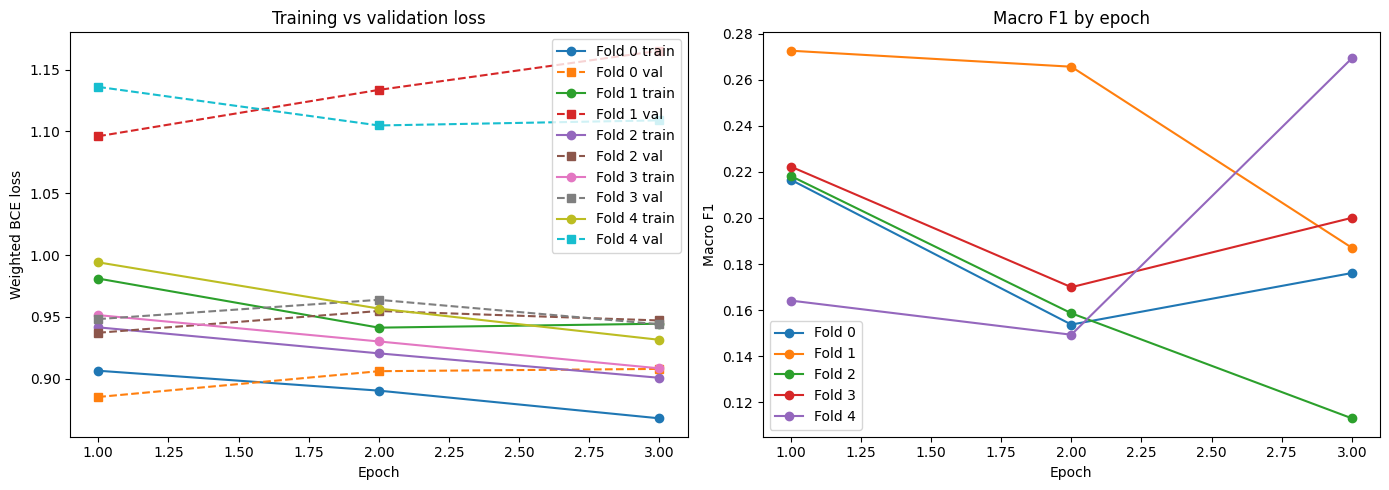

In [19]:
# ==================================================
# 18 — Training curves
# ==================================================

history_all = pd.concat(
    all_histories,
    ignore_index=True
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for fold in sorted(history_all["fold"].unique()):
    h = history_all[
        history_all["fold"] == fold
    ]

    axes[0].plot(
        h["epoch"],
        h["train_loss"],
        marker="o",
        label=f"Fold {fold} train"
    )

    axes[0].plot(
        h["epoch"],
        h["val_loss"],
        marker="s",
        linestyle="--",
        label=f"Fold {fold} val"
    )

axes[0].set_title("Training vs validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted BCE loss")
axes[0].legend()

for fold in sorted(history_all["fold"].unique()):
    h = history_all[
        history_all["fold"] == fold
    ]

    axes[1].plot(
        h["epoch"],
        h["macro_f1"],
        marker="o",
        label=f"Fold {fold}"
    )

axes[1].set_title("Macro F1 by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()

plt.tight_layout()
plt.show()

history_all.to_csv(
    "/kaggle/working/efficientnet_b0_all_history.csv",
    index=False
)


,label,positive_count,roc_auc,pr_auc,precision,recall,specificity,f1,tp,tn,fp,fn
0,ACL,24,0.573529,0.568163,0.500000,0.333333,0.764706,0.400000,8,26,8,16
1,MCL,9,0.469388,0.169477,NaN,0.000000,1.000000,0.000000,0,49,0,9
2,Medial Meniscus,26,0.518029,0.508608,0.545455,0.230769,0.843750,0.324324,6,27,5,20
3,Lateral Meniscus,23,0.510559,0.434962,0.500000,0.043478,0.971429,0.080000,1,34,1,22
4,Medial OA,15,0.508527,0.279555,0.500000,0.066667,0.976744,0.117647,1,42,1,14
5,Lateral OA,11,0.282398,0.138597,0.000000,0.000000,0.936170,0.000000,0,44,3,11
6,PF OA,21,0.567568,0.405900,0.409091,0.428571,0.648649,0.418605,9,24,13,12
7,Effusion,35,0.493168,0.627856,0.607143,0.971429,0.043478,0.747253,34,1,22,1
8,Synovitis,27,0.431302,0.419899,0.400000,0.148148,0.806452,0.216216,4,25,6,23
9,Baker's,12,0.567029,0.271941,NaN,0.000000,1.000000,0.000000,0,46,0,12


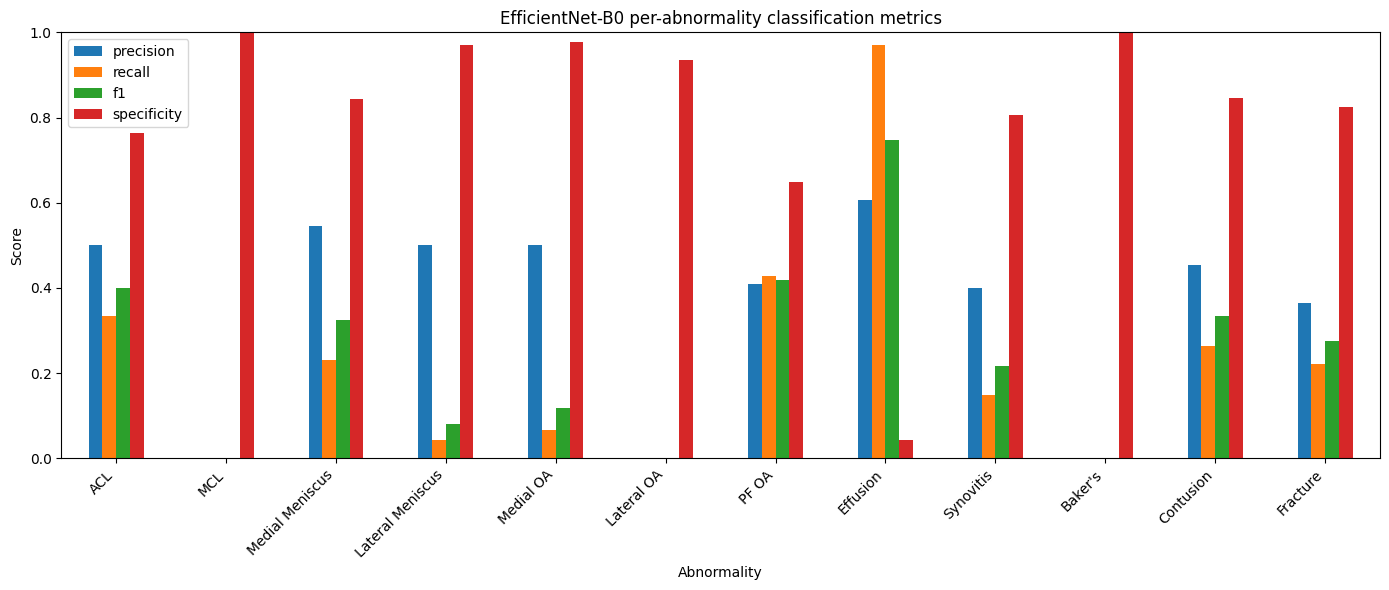

In [20]:
# ==================================================
# 19 — OOF per-class evaluation
# ==================================================

# Use all available OOF predictions from the completed folds.
true_cols = [
    f"{label}_true"
    for label in LABEL_COLS
]

prob_cols = [
    f"{label}_prob"
    for label in LABEL_COLS
]

oof_true = all_predictions_df[
    true_cols
].values.astype(int)

oof_prob = all_predictions_df[
    prob_cols
].values.astype(float)

oof_per_class = compute_per_class_metrics(
    oof_true,
    oof_prob
)

display(
    oof_per_class[
        [
            "label",
            "positive_count",
            "roc_auc",
            "pr_auc",
            "precision",
            "recall",
            "specificity",
            "f1",
            "tp",
            "tn",
            "fp",
            "fn"
        ]
    ]
)

oof_per_class.to_csv(
    "/kaggle/working/"
    "efficientnet_b0_oof_per_class_metrics.csv",
    index=False
)

# Macro bar chart.
plot_df = oof_per_class.set_index("label")[
    [
        "precision",
        "recall",
        "f1",
        "specificity"
    ]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

ax.set_title(
    "EfficientNet-B0 per-abnormality classification metrics"
)
ax.set_ylabel("Score")
ax.set_xlabel("Abnormality")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


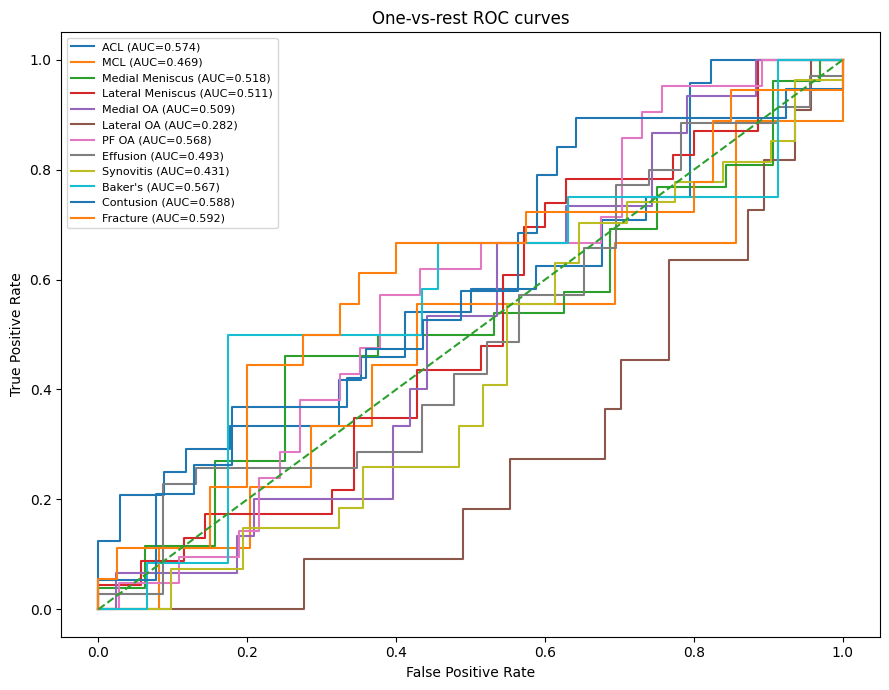

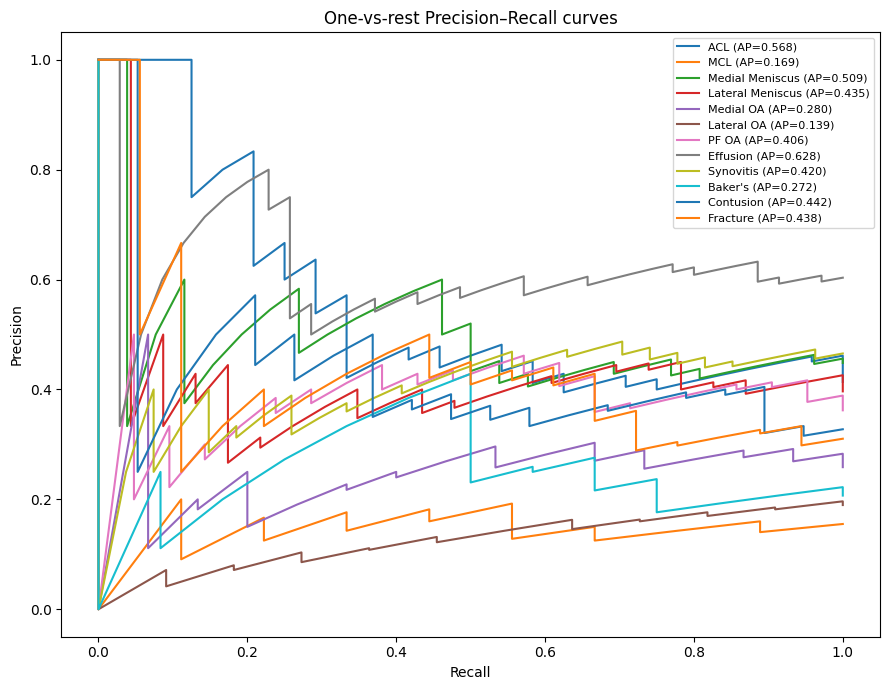

In [21]:
# ==================================================
# 20 — ROC / PR curves
# ==================================================

valid_labels = []

for j, label in enumerate(LABEL_COLS):
    if len(np.unique(oof_true[:, j])) == 2:
        valid_labels.append((j, label))

if not valid_labels:
    print(
        "ROC/PR curves skipped: the current OOF subset "
        "does not contain both classes for any label."
    )
else:
    # ROC
    plt.figure(figsize=(9, 7))

    for j, label in valid_labels:
        fpr, tpr, _ = roc_curve(
            oof_true[:, j],
            oof_prob[:, j]
        )

        auc = roc_auc_score(
            oof_true[:, j],
            oof_prob[:, j]
        )

        plt.plot(
            fpr,
            tpr,
            label=f"{label} (AUC={auc:.3f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-rest ROC curves")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # Precision-recall
    plt.figure(figsize=(9, 7))

    for j, label in valid_labels:
        precision, recall, _ = precision_recall_curve(
            oof_true[:, j],
            oof_prob[:, j]
        )

        ap = average_precision_score(
            oof_true[:, j],
            oof_prob[:, j]
        )

        plt.plot(
            recall,
            precision,
            label=f"{label} (AP={ap:.3f})"
        )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("One-vs-rest Precision–Recall curves")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [22]:
# ==================================================
# 21 — Study-level error analysis
# ==================================================

oof_pred = (
    oof_prob >= CLASSIFICATION_THRESHOLD
).astype(int)

study_error_rows = []

for i in range(len(all_predictions_df)):
    true_i = oof_true[i]
    pred_i = oof_pred[i]

    incorrect = np.where(
        true_i != pred_i
    )[0]

    study_error_rows.append({
        "StudyInstanceUID": all_predictions_df.iloc[i]["StudyInstanceUID"],
        "fold": all_predictions_df.iloc[i]["fold"],
        "num_label_errors": int(len(incorrect)),
        "false_positive_labels": ", ".join(
            LABEL_COLS[j]
            for j in incorrect
            if pred_i[j] == 1 and true_i[j] == 0
        ),
        "false_negative_labels": ", ".join(
            LABEL_COLS[j]
            for j in incorrect
            if pred_i[j] == 0 and true_i[j] == 1
        )
    })

error_df = pd.DataFrame(
    study_error_rows
).sort_values(
    "num_label_errors",
    ascending=False
)

display(
    error_df.head(10)
)

error_df.to_csv(
    "/kaggle/working/"
    "efficientnet_b0_oof_error_analysis.csv",
    index=False
)

print(
    "\nTotal study-level error cases:",
    int((error_df["num_label_errors"] > 0).sum())
)

print(
    "Mean label errors per study:",
    error_df["num_label_errors"].mean()
)


,StudyInstanceUID,fold,num_label_errors,false_positive_labels,false_negative_labels
43,1.2.826.0.1.3680043.8.498.65708905118633339771...,3,8,"ACL, Fracture","Medial Meniscus, Lateral Meniscus, Medial OA, ..."
50,1.2.826.0.1.3680043.8.498.16060119389060497136...,4,8,,"Medial Meniscus, Lateral Meniscus, Medial OA, ..."
23,1.2.826.0.1.3680043.8.498.88077418639301174409...,1,7,,"Medial Meniscus, Lateral Meniscus, Medial OA, ..."
36,1.2.826.0.1.3680043.8.498.10170898615867673028...,3,7,"ACL, Effusion, Contusion, Fracture","Lateral Meniscus, PF OA, Synovitis"
11,1.2.826.0.1.3680043.8.498.82166943552764439138...,0,7,"PF OA, Synovitis","ACL, Medial Meniscus, Lateral Meniscus, Medial..."
24,1.2.826.0.1.3680043.8.498.11915937982684988073...,2,6,Medial Meniscus,"Lateral Meniscus, Lateral OA, PF OA, Synovitis..."
26,1.2.826.0.1.3680043.8.498.13267780356245120052...,2,6,"ACL, PF OA, Effusion, Synovitis","Lateral Meniscus, Fracture"
29,1.2.826.0.1.3680043.8.498.29764868091238287072...,2,6,"Medial Meniscus, PF OA, Effusion","ACL, Contusion, Fracture"
53,1.2.826.0.1.3680043.8.498.32321830776739689645...,4,6,,"ACL, MCL, PF OA, Synovitis, Contusion, Fracture"
38,1.2.826.0.1.3680043.8.498.22109739962224309418...,3,6,"Effusion, Fracture","Lateral Meniscus, Medial OA, Lateral OA, Baker's"



Total study-level error cases: 57
Mean label errors per study: 4.137931034482759


## Reproducibility outputs

The notebook saves fold metrics, out-of-fold predictions, training history, per-abnormality metrics, error analysis and a comparison-ready EfficientNet row. These artifacts can be merged with the corresponding outputs from the other models for the final comparison table.

In [23]:
# ==================================================
# 22 — List generated artifacts
# ==================================================

expected_outputs = [
    "efficientnet_b0_fold_results.csv",
    "efficientnet_b0_oof_predictions.csv",
    "efficientnet_b0_metric_summary.csv",
    "efficientnet_b0_comparison_row.csv",
    "efficientnet_b0_all_history.csv",
    "efficientnet_b0_oof_per_class_metrics.csv",
    "efficientnet_b0_oof_error_analysis.csv"
]

print("Expected experiment artifacts:")
for name in expected_outputs:
    path = os.path.join("/kaggle/working", name)
    print(
        f"{'OK  ' if os.path.exists(path) else 'MISS'} {name}"
    )


Expected experiment artifacts:
OK   efficientnet_b0_fold_results.csv
OK   efficientnet_b0_oof_predictions.csv
OK   efficientnet_b0_metric_summary.csv
OK   efficientnet_b0_comparison_row.csv
OK   efficientnet_b0_all_history.csv
OK   efficientnet_b0_oof_per_class_metrics.csv
OK   efficientnet_b0_oof_error_analysis.csv
